In [1]:
import sys
import os

# Adds the parent directory to the python path
sys.path.append(os.path.abspath(os.path.join('..')))

In [2]:
import torch
import torch.nn as nn

from datasets import load_dataset
from torch.utils.data import DataLoader

from src.data.transformer_dataset import IMDBTransformerDataset
from src.models.transformer import TransformerClassifier
from src.training.trainer import Trainer

C:\Users\Dell\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from src.data.vocabulary import Vocabulary

In [4]:
## load imbd dataset

dataset = load_dataset("stanfordnlp/imdb")

train_texts = dataset["train"]["text"]
train_labels = dataset["train"]["label"]

val_texts = dataset["test"]["text"]
val_labels = dataset["test"]["label"]

In [5]:
## reproducibility
import random
import numpy as np
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [6]:
## building the vocabulary

MAX_VOCAB_SIZE = 10_000
MAX_LENGTH = 500

vocab = Vocabulary(max_size=MAX_VOCAB_SIZE)

print("Before build:", len(vocab.word_to_id))

vocab.build(train_texts)

print("After build:", len(vocab.word_to_id))
print("First 20 words:")
print(list(vocab.word_to_id.items())[:20])

Before build: 2
After build: 10000
First 20 words:
[('<PAD>', 0), ('<UNK>', 1), ('the', 2), ('and', 3), ('a', 4), ('of', 5), ('to', 6), ('is', 7), ('in', 8), ('it', 9), ('i', 10), ('this', 11), ('that', 12), ('br', 13), ('was', 14), ('as', 15), ('for', 16), ('with', 17), ('movie', 18), ('but', 19)]


In [7]:
## transformer dataset and dataloader

train_dataset = IMDBTransformerDataset(
    texts=train_texts,
    labels=train_labels,
    vocabulary=vocab,
    max_length=MAX_LENGTH
)

val_dataset = IMDBTransformerDataset(
    texts=val_texts,
    labels=val_labels,
    vocabulary=vocab,
    max_length=MAX_LENGTH
)

In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
)

In [9]:
trans_model = TransformerClassifier(
    vocab_size=len(vocab.word_to_id),
    embedding_dim=128,
    num_heads=4,
    num_layers=2,
    feedforward_dim=256,
    dropout=0.1,
    padding_idx=0,
    max_length=MAX_LENGTH,
)

In [10]:
trans_model

TransformerClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (positional_embedding): Embedding(500, 128)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

In [11]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [12]:
trans_model = trans_model.to(device)

In [13]:
trans_model

TransformerClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (positional_embedding): Embedding(500, 128)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

In [14]:
## training configuration
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    trans_model.parameters(),
    lr=1e-3,
)

In [15]:
trainer = Trainer(
    model=trans_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    checkpoint_path="checkpoints/transformer/transformer_best.pt",
)

In [16]:
## training the model

history = trainer.fit(
    epochs=5
)

c:\Data science-2\Simple-RNN-IMDB\venv\Lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:181.)
  output = torch._nested_tensor_from_mask(


  -> Best model saved.
Epoch 01 | Train Loss: 0.4546 | Train Acc: 0.7732 | Val Loss: 0.3733 | Val Acc: 0.8323
  -> Best model saved.
Epoch 02 | Train Loss: 0.2937 | Train Acc: 0.8787 | Val Loss: 0.3517 | Val Acc: 0.8502
Epoch 03 | Train Loss: 0.2297 | Train Acc: 0.9078 | Val Loss: 0.3729 | Val Acc: 0.8470
Epoch 04 | Train Loss: 0.2075 | Train Acc: 0.9183 | Val Loss: 0.3918 | Val Acc: 0.8417
Epoch 05 | Train Loss: 0.2060 | Train Acc: 0.9189 | Val Loss: 0.4273 | Val Acc: 0.8236


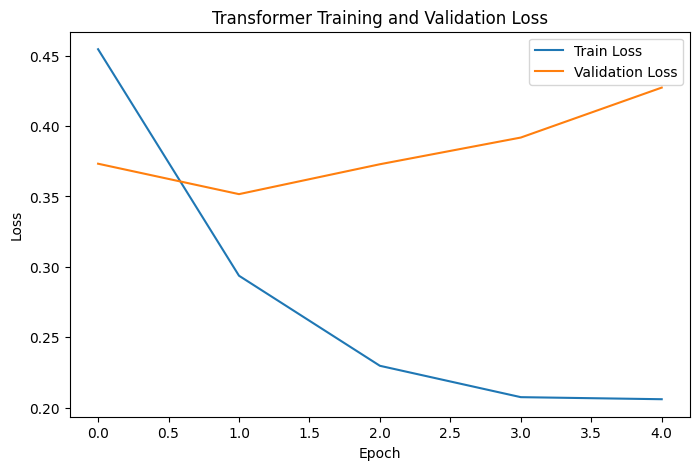

In [17]:
## Learning curves

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history["train_loss"],
    label="Train Loss",
)

plt.plot(
    history["val_loss"],
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Training and Validation Loss")
plt.legend()

save_dir = "plots/transformer/"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, "transformer_loss_curve.png"), dpi=300, bbox_inches="tight")


plt.show()

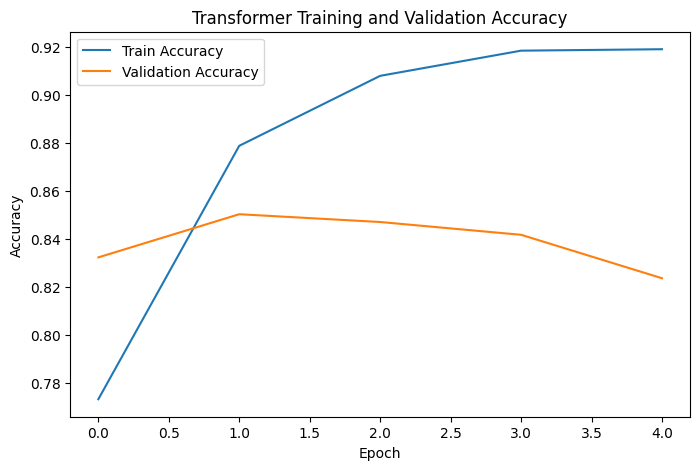

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_accuracy"],
    label="Train Accuracy",
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transformer Training and Validation Accuracy")
plt.legend()

save_dir = "plots/transformer/"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, "transformer_accuracy_curve.png"), dpi=300, bbox_inches="tight")

plt.show()

In [19]:
## loading the best plot

checkpoint_path = "checkpoints/transformer/transformer_best.pt"

trans_model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device,
    )
)

trans_model.eval()
print("Loaded:", checkpoint_path)

Loaded: checkpoints/transformer/transformer_best.pt


In [20]:
## Validation evaluation

val_loss, val_accuracy = trainer.validate()

print("Validation Loss    :", val_loss)
print("Validation Accuracy:", val_accuracy)

Validation Loss    : 0.35165572700977327
Validation Accuracy: 0.85024


In [21]:
labels, predictions, probabilities = trainer.predict(
    val_loader
)

In [22]:
from src.evaluation.metrics import (
    calculate_metrics,
    calculate_confusion_matrix,
)

In [23]:
validation_metrics = calculate_metrics(
    labels,
    predictions,
    probabilities,
)

print(validation_metrics)

{'accuracy': 0.85024, 'precision': 0.8205447356860448, 'recall': 0.89656, 'f1': 0.8568697912684456, 'roc_auc': np.float64(0.9313333792)}


In [24]:
# import numpy as np

# labels = np.array(labels)
# predictions = np.array(predictions)
# probabilities = np.array(probabilities)

In [25]:
# labels, predictions, probabilities

In [26]:
## confusion matrix

cm = calculate_confusion_matrix(
    labels,
    predictions,
)

print(cm)

[[10049  2451]
 [ 1293 11207]]


### Same thing again

In [27]:
## test evaluation

test_labels, test_predictions, test_probabilities = (
    trainer.predict(val_loader)
)

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

In [29]:
trans_metrics = {
    "accuracy": accuracy_score(
        test_labels,
        test_predictions,
    ),

    "precision": precision_score(
        test_labels,
        test_predictions,
    ),

    "recall": recall_score(
        test_labels,
        test_predictions,
    ),

    "f1": f1_score(
        test_labels,
        test_predictions,
    ),

    "roc_auc": roc_auc_score(
        test_labels,
        test_probabilities,
    ),
}

print(trans_metrics)

{'accuracy': 0.85024, 'precision': 0.8205447356860448, 'recall': 0.89656, 'f1': 0.8568697912684456, 'roc_auc': np.float64(0.9313333792)}


In [30]:
cm = confusion_matrix(
    test_labels,
    test_predictions,
)

print(cm)

[[10049  2451]
 [ 1293 11207]]


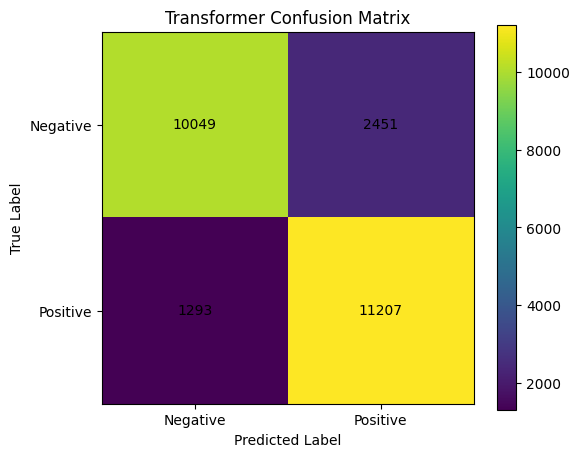

In [31]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Transformer Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    [0, 1],
    ["Negative", "Positive"],
)

plt.yticks(
    [0, 1],
    ["Negative", "Positive"],
)

plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
        )

save_dir = "plots/transformer/"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, "transformer_confusion_matrix.png"), dpi=300, bbox_inches="tight")

plt.show()

In [32]:
## Final test set evaluation

test_y_true, test_y_pred, test_y_prob = trainer.predict(
    val_loader
)

test_metrics = calculate_metrics(
    test_y_true,
    test_y_pred,
    test_y_prob,
)

print("Test Metrics")
print("-" * 40)

for metric_name, value in test_metrics.items():
    print(f"{metric_name:12s}: {float(value):.4f}")

Test Metrics
----------------------------------------
accuracy    : 0.8502
precision   : 0.8205
recall      : 0.8966
f1          : 0.8569
roc_auc     : 0.9313


In [33]:
def count_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

print(
    "Transformer parameters:",
    count_parameters(trans_model)
)

Transformer parameters: 1609089


In [34]:
## getting parameters count for the rest

from src.models.rnn import SimpleRNNClassifier
from src.models.lstm import LSTMClassifier
from src.models.bilstm import BiLSTMClassifier


embedding_dim = 128
hidden_dim = 128
num_layers = 1
dropout = 0.0

In [35]:
rnn_model = SimpleRNNClassifier(
    vocab_size=len(vocab.id_to_word),
    embedding_dim=128,
    hidden_dim=128,
    num_layers=1,
    dropout=0.0,
)

lstm_model = LSTMClassifier(
    vocab_size=len(vocab.id_to_word),
    embedding_dim=128,
    hidden_dim=128,
    num_layers=1,
    dropout=0.0,
)

bilstm_model = BiLSTMClassifier(
    vocab_size=len(vocab.id_to_word),
    embedding_dim=128,
    hidden_dim=128,
    num_layers=1,
    dropout=0.0,
)

In [36]:
print("RNN parameters     :", count_parameters(rnn_model))
print("LSTM parameters    :", count_parameters(lstm_model))
print("BiLSTM parameters  :", count_parameters(bilstm_model))
print("Transformer params :", count_parameters(trans_model))

RNN parameters     : 1313153
LSTM parameters    : 1412225
BiLSTM parameters  : 1544449
Transformer params : 1609089


## Model Comparison and Analysis

Four architectures were evaluated using the same IMDB sentiment classification
task: Simple RNN, LSTM, BiLSTM, and a Transformer Encoder.

The results show a clear progression in performance. The Simple RNN achieved
75.45% accuracy, while the LSTM improved this to 83.73%. The BiLSTM further
increased accuracy to 85.42%, and the Transformer achieved the highest accuracy
at 85.68%.

The largest improvement occurred when moving from the Simple RNN to the LSTM,
suggesting that improved handling of sequential dependencies provided substantial
benefit for this task. The BiLSTM produced another improvement by incorporating
context from both directions.

The Transformer achieved the best overall results, with 85.68% accuracy,
85.57% F1, and 93.33% ROC-AUC. However, its improvement over the BiLSTM was
relatively small. This indicates that the BiLSTM was already a strong baseline
for the chosen dataset and experimental configuration.

The results also demonstrate diminishing performance gains as the architectures
become more sophisticated. Therefore, the Transformer should not be interpreted
as universally superior based on this experiment alone; rather, it provided a
modest improvement under the specific model sizes, sequence length, vocabulary,
and training configuration used here.

## Training Behavior

The Transformer reached its best validation performance at Epoch 2. After this
point, training accuracy continued to increase while validation performance
declined.

This indicates that the model began to overfit the training data after the
second epoch. The best checkpoint was therefore selected using validation loss
rather than using the final training epoch.

### Build an error-analysis DtaFrame

In [37]:
## error analysis

import pandas as pd
import numpy as np

error_analysis = pd.DataFrame({
    "text": val_texts,
    "true_label": labels,
    "predicted_label": predictions,
    "probability": probabilities,
})

error_analysis["confidence"] = np.where(
    error_analysis["predicted_label"] == 1,
    error_analysis["probability"],
    1 - error_analysis["probability"],
)

error_analysis["correct"] = (
    error_analysis["true_label"]
    == error_analysis["predicted_label"]
)

error_analysis.head()

,text,true_label,predicted_label,probability,confidence,correct
0,I love sci-fi and am willing to put up with a ...,0.0,False,0.005198,0.994802,True
1,"Worth the entertainment value of a rental, esp...",0.0,False,0.239999,0.760001,True
2,its a totally average film with a few semi-alr...,0.0,False,0.106951,0.893049,True
3,STAR RATING: ***** Saturday Night **** Friday ...,0.0,False,0.054618,0.945382,True
4,"First off let me say, If you haven't enjoyed a...",0.0,True,0.985855,0.985855,False


In [ ]:
##Verify the counts

print("Total samples:", len(error_analysis))

print(
    "Correct predictions:",
    error_analysis["correct"].sum()
)

print(
    "Incorrect predictions:",
    (~error_analysis["correct"]).sum()
)

Total samples: 25000
Correct predictions: 21256
Incorrect predictions: 3744


In [39]:
##Separate the four prediction categories

true_positive = error_analysis[
    (error_analysis["true_label"] == 1)
    & (error_analysis["predicted_label"] == 1)
]

true_negative = error_analysis[
    (error_analysis["true_label"] == 0)
    & (error_analysis["predicted_label"] == 0)
]

false_positive = error_analysis[
    (error_analysis["true_label"] == 0)
    & (error_analysis["predicted_label"] == 1)
]

false_negative = error_analysis[
    (error_analysis["true_label"] == 1)
    & (error_analysis["predicted_label"] == 0)
]

In [40]:
print("True Positives :", len(true_positive))
print("True Negatives :", len(true_negative))
print("False Positives:", len(false_positive))
print("False Negatives:", len(false_negative))

True Positives : 11207
True Negatives : 10049
False Positives: 2451
False Negatives: 1293


In [ ]:
##Examine the most confident mistakes

high_confidence_errors = error_analysis[
    ~error_analysis["correct"]
].sort_values(
    "confidence",
    ascending=False,
)

high_confidence_errors[
    [
        "text",
        "true_label",
        "predicted_label",
        "probability",
        "confidence",
    ]
].head(10)

,text,true_label,predicted_label,probability,confidence
5220,Primary plot!Primary direction!Poor interpreta...,0.0,True,0.998959,0.998959
23647,black tar can't be snorted there's a documenta...,1.0,False,0.001553,0.998447
4118,This is definitely one of the best Kung fu mov...,0.0,True,0.998434,0.998434
18713,"I enjoyed this series, but felt that the whole...",1.0,False,0.001567,0.998433
9462,I saw this movie in 1956 and again on Cable a ...,0.0,True,0.998296,0.998296
11234,I have recently found this film on one of my h...,0.0,True,0.997962,0.997962
3553,"This film has the language, the style and the ...",0.0,True,0.997833,0.997833
12061,This movie was pure genius. John Waters is bri...,0.0,True,0.997701,0.997701
5331,I enjoyed the beautiful scenery in this movie ...,0.0,True,0.997625,0.997625
3692,"Another direct to video movie from Disney, tha...",0.0,True,0.997418,0.997418


In [42]:
## inspect the false positives

false_positive.sort_values(
    "confidence",
    ascending=False,
)[
    [
        "text",
        "true_label",
        "predicted_label",
        "probability",
        "confidence",
    ]
].head(5)

,text,true_label,predicted_label,probability,confidence
5220,Primary plot!Primary direction!Poor interpreta...,0.0,True,0.998959,0.998959
4118,This is definitely one of the best Kung fu mov...,0.0,True,0.998434,0.998434
9462,I saw this movie in 1956 and again on Cable a ...,0.0,True,0.998296,0.998296
11234,I have recently found this film on one of my h...,0.0,True,0.997962,0.997962
3553,"This film has the language, the style and the ...",0.0,True,0.997833,0.997833


In [43]:
## inspect the false negatives

false_negative.sort_values(
    "confidence",
    ascending=False,
)[
    [
        "text",
        "true_label",
        "predicted_label",
        "probability",
        "confidence",
    ]
].head(5)

,text,true_label,predicted_label,probability,confidence
23647,black tar can't be snorted there's a documenta...,1.0,False,0.001553,0.998447
18713,"I enjoyed this series, but felt that the whole...",1.0,False,0.001567,0.998433
15074,When the movie first started I thought cheesy....,1.0,False,0.002666,0.997334
18928,What about DJ Cash Money??? This film fails in...,1.0,False,0.002874,0.997126
17942,"Actually I'll admit I'm a political junkie, so...",1.0,False,0.004845,0.995155


## Trying again by reloading the best checkpoint again

In [44]:
## reload the best checkpoint again

best_checkpoint = "checkpoints/transformer/transformer_best.pt"

trans_model.load_state_dict(
    torch.load(
        best_checkpoint,
        map_location=device,
    )
)

transformer_model = trans_model.to(device)
transformer_model.eval()

print("Best checkpoint loaded.")

Best checkpoint loaded.


In [45]:
labels, predictions, probabilities = trainer.predict(
    val_loader
)

In [46]:
import numpy as np

labels = np.array(labels).astype(int)
predictions = np.array(predictions).astype(int)
probabilities = np.array(probabilities)

In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

print("Accuracy :", accuracy_score(labels, predictions))
print("Precision:", precision_score(labels, predictions))
print("Recall   :", recall_score(labels, predictions))
print("F1       :", f1_score(labels, predictions))
print("ROC-AUC  :", roc_auc_score(labels, probabilities))

print("\nConfusion Matrix:")
print(confusion_matrix(labels, predictions))

Accuracy : 0.85024
Precision: 0.8205447356860448
Recall   : 0.89656
F1       : 0.8568697912684456
ROC-AUC  : 0.9313333792

Confusion Matrix:
[[10049  2451]
 [ 1293 11207]]


In [48]:
error_analysis = pd.DataFrame({
    "text": val_texts,
    "true_label": labels,
    "predicted_label": predictions,
    "probability": probabilities,
})

error_analysis["confidence"] = np.where(
    error_analysis["predicted_label"] == 1,
    error_analysis["probability"],
    1 - error_analysis["probability"],
)

error_analysis["correct"] = (
    error_analysis["true_label"]
    == error_analysis["predicted_label"]
)

In [49]:
print("Total samples:", len(error_analysis))
print("Correct predictions:", error_analysis["correct"].sum())
print("Incorrect predictions:", (~error_analysis["correct"]).sum())

Total samples: 25000
Correct predictions: 21256
Incorrect predictions: 3744


### Test prediction determinism

In [51]:
trans_model.load_state_dict(
    torch.load(
        "checkpoints/transformer/transformer_best.pt",
        map_location=device,
    )
)

trans_model.to(device)
trans_model.eval()

labels_1, predictions_1, probabilities_1 = trainer.predict(
    val_loader
)

labels_2, predictions_2, probabilities_2 = trainer.predict(
    val_loader
)

In [52]:
import numpy as np

predictions_1 = np.array(predictions_1)
predictions_2 = np.array(predictions_2)

probabilities_1 = np.array(probabilities_1)
probabilities_2 = np.array(probabilities_2)

print(
    "Predictions identical:",
    np.array_equal(predictions_1, predictions_2)
)

print(
    "Probabilities identical:",
    np.allclose(probabilities_1, probabilities_2)
)

Predictions identical: True
Probabilities identical: True


In [53]:
## checking the checkpoint file

from pathlib import Path

checkpoint_path = Path("checkpoints/transformer/transformer_best.pt")

print("Checkpoint exists:", checkpoint_path.exists())

if checkpoint_path.exists():
    print("Checkpoint path :", checkpoint_path.resolve())
    print("Checkpoint size :", checkpoint_path.stat().st_size, "bytes")
    print("Last modified   :", checkpoint_path.stat().st_mtime)

Checkpoint exists: True
Checkpoint path : C:\Data science-2\Simple-RNN-IMDB\notebooks\checkpoints\transformer\transformer_best.pt
Checkpoint size : 6447873 bytes
Last modified   : 1788426185.2850802


In [54]:
checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
)

print("Checkpoint type:", type(checkpoint))

Checkpoint type: <class 'collections.OrderedDict'>


In [55]:
checkpoint_model = TransformerClassifier(
    vocab_size=len(vocab.word_to_id),
    embedding_dim=128,
    num_heads=4,
    num_layers=2,
    feedforward_dim=256,
    dropout=0.1,
    padding_idx=0,
    max_length=500,
)

checkpoint_model.load_state_dict(
    checkpoint,
)

checkpoint_model = checkpoint_model.to(device)
checkpoint_model.eval()

TransformerClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (positional_embedding): Embedding(500, 128)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

In [56]:
all_probabilities = []
all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch[0].to(device)
        labels_batch = batch[1].to(device)
        attention_mask = batch[2].to(device)

        logits = checkpoint_model(
            input_ids,
            attention_mask,
        )

        probabilities_batch = torch.sigmoid(logits)
        predictions_batch = probabilities_batch >= 0.5

        all_labels.extend(labels_batch.cpu().numpy())
        all_predictions.extend(predictions_batch.cpu().numpy())
        all_probabilities.extend(probabilities_batch.cpu().numpy())

In [57]:
all_labels = np.array(all_labels).astype(int)
all_predictions = np.array(all_predictions).astype(int)
all_probabilities = np.array(all_probabilities)

In [58]:
print("Accuracy :", accuracy_score(all_labels, all_predictions))
print("Precision:", precision_score(all_labels, all_predictions))
print("Recall   :", recall_score(all_labels, all_predictions))
print("F1       :", f1_score(all_labels, all_predictions))
print("ROC-AUC  :", roc_auc_score(all_labels, all_probabilities))

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_predictions))

Accuracy : 0.85024
Precision: 0.8205447356860448
Recall   : 0.89656
F1       : 0.8568697912684456
ROC-AUC  : 0.9313333792

Confusion Matrix:
[[10049  2451]
 [ 1293 11207]]


### Lets return to error analysis

In [59]:
## inspect the actual high confidence errors again

high_confidence_errors = error_analysis[
    ~error_analysis["correct"]
].sort_values(
    "confidence",
    ascending=False,
)

high_confidence_errors[
    [
        "text",
        "true_label",
        "predicted_label",
        "probability",
        "confidence",
    ]
].head(10)

,text,true_label,predicted_label,probability,confidence
5220,Primary plot!Primary direction!Poor interpreta...,0,1,0.998959,0.998959
23647,black tar can't be snorted there's a documenta...,1,0,0.001553,0.998447
4118,This is definitely one of the best Kung fu mov...,0,1,0.998434,0.998434
18713,"I enjoyed this series, but felt that the whole...",1,0,0.001567,0.998433
9462,I saw this movie in 1956 and again on Cable a ...,0,1,0.998296,0.998296
11234,I have recently found this film on one of my h...,0,1,0.997962,0.997962
3553,"This film has the language, the style and the ...",0,1,0.997833,0.997833
12061,This movie was pure genius. John Waters is bri...,0,1,0.997701,0.997701
5331,I enjoyed the beautiful scenery in this movie ...,0,1,0.997625,0.997625
3692,"Another direct to video movie from Disney, tha...",0,1,0.997418,0.997418


In [60]:
print("=== FALSE POSITIVES ===")

false_positive = error_analysis[
    (error_analysis["true_label"] == 0)
    & (error_analysis["predicted_label"] == 1)
]

false_positive.sort_values(
    "confidence",
    ascending=False,
)[
    [
        "text",
        "true_label",
        "predicted_label",
        "probability",
        "confidence",
    ]
].head(10)

=== FALSE POSITIVES ===


,text,true_label,predicted_label,probability,confidence
5220,Primary plot!Primary direction!Poor interpreta...,0,1,0.998959,0.998959
4118,This is definitely one of the best Kung fu mov...,0,1,0.998434,0.998434
9462,I saw this movie in 1956 and again on Cable a ...,0,1,0.998296,0.998296
11234,I have recently found this film on one of my h...,0,1,0.997962,0.997962
3553,"This film has the language, the style and the ...",0,1,0.997833,0.997833
12061,This movie was pure genius. John Waters is bri...,0,1,0.997701,0.997701
5331,I enjoyed the beautiful scenery in this movie ...,0,1,0.997625,0.997625
3692,"Another direct to video movie from Disney, tha...",0,1,0.997418,0.997418
9182,"I loved the first ""American Graffiti"" with all...",0,1,0.997400,0.997400
6678,I first saw this movie at a Saturday matinee w...,0,1,0.997272,0.997272


In [61]:
print("=== FALSE NEGATIVES ===")

false_negative = error_analysis[
    (error_analysis["true_label"] == 1)
    & (error_analysis["predicted_label"] == 0)
]

false_negative.sort_values(
    "confidence",
    ascending=False,
)[
    [
        "text",
        "true_label",
        "predicted_label",
        "probability",
        "confidence",
    ]
].head(10)

=== FALSE NEGATIVES ===


,text,true_label,predicted_label,probability,confidence
23647,black tar can't be snorted there's a documenta...,1,0,0.001553,0.998447
18713,"I enjoyed this series, but felt that the whole...",1,0,0.001567,0.998433
15074,When the movie first started I thought cheesy....,1,0,0.002666,0.997334
18928,What about DJ Cash Money??? This film fails in...,1,0,0.002874,0.997126
17942,"Actually I'll admit I'm a political junkie, so...",1,0,0.004845,0.995155
19474,Newly-pregnant Knight bolts from husband for n...,1,0,0.006146,0.993854
20621,This was Laurel and Hardy's last silent film f...,1,0,0.007221,0.992779
16581,This movie turned out to be better than I had ...,1,0,0.008257,0.991743
19591,House of Dracula works from the same basic pre...,1,0,0.008373,0.991627
17868,My sisters and my cousin(female) forced me to ...,1,0,0.009230,0.990770


In [62]:
## lets measure review truncation

token_lengths = np.array([
    len(vocab.tokenize(text))
    for text in val_texts
])

print("Total reviews:", len(token_lengths))
print("Reviews > 500 tokens:", np.sum(token_lengths > 500))
print(
    "Percentage > 500:",
    np.mean(token_lengths > 500) * 100
)

print("Maximum tokenized length:", token_lengths.max())
print("Mean tokenized length:", token_lengths.mean())
print("Median tokenized length:", np.median(token_lengths))

Total reviews: 25000
Reviews > 500 tokens: 1859
Percentage > 500: 7.436
Maximum tokenized length: 2267
Mean tokenized length: 226.55388
Median tokenized length: 171.0


In [63]:
#### Compare errors by review length

error_analysis["token_length"] = token_lengths

In [64]:
error_analysis["length_group"] = pd.cut(
    error_analysis["token_length"],
    bins=[0, 100, 200, 300, 400, 500, np.inf],
    labels=[
        "0-100",
        "101-200",
        "201-300",
        "301-400",
        "401-500",
        "500+",
    ],
)

In [65]:
length_analysis = (
    error_analysis
    .groupby("length_group", observed=True)
    .agg(
        reviews=("correct", "size"),
        errors=("correct", lambda x: (~x).sum()),
        accuracy=("correct", "mean"),
    )
)

length_analysis["error_rate"] = 1 - length_analysis["accuracy"]

length_analysis

,reviews,errors,accuracy,error_rate
length_group,,,,
0-100,3201,434,0.864417,0.135583
101-200,11841,1756,0.851702,0.148298
201-300,4616,686,0.851386,0.148614
301-400,2259,340,0.849491,0.150509
401-500,1224,183,0.850490,0.149510
500+,1859,345,0.814416,0.185584


In [66]:
short_reviews = error_analysis["token_length"] <= 500
long_reviews = error_analysis["token_length"] > 500

print("Error rate <= 500 tokens:",
      (~error_analysis.loc[short_reviews, "correct"]).mean())

print("Error rate > 500 tokens:",
      (~error_analysis.loc[long_reviews, "correct"]).mean())

Error rate <= 500 tokens: 0.1468821572101465
Error rate > 500 tokens: 0.18558364712210865


Now we have evidence that truncation is contributing to the Transformer’s errors.

| Review length |   Reviews | Error rate |
| ------------- | --------: | ---------: |
| 0–100         |     3,201 |     13.56% |
| 101–200       |    11,841 |     14.83% |
| 201–300       |     4,616 |     14.86% |
| 301–400       |     2,259 |     15.05% |
| 401–500       |     1,224 |     14.95% |
| **500+**      | **1,859** | **18.56%** |


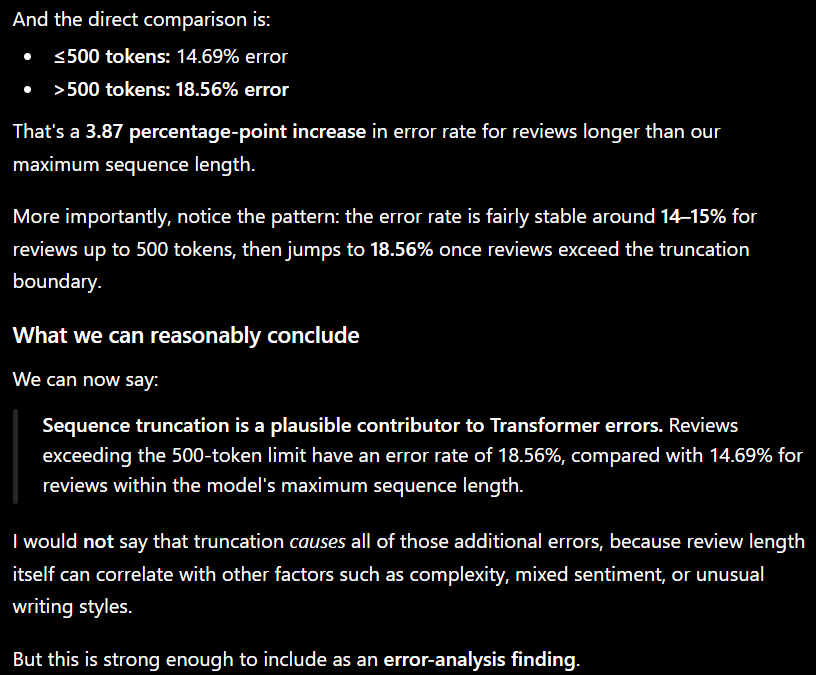

In [67]:
long_errors = error_analysis[
    (error_analysis["token_length"] > 500) &
    (~error_analysis["correct"])
]

print("Errors in reviews > 500 tokens:", len(long_errors))
print(
    "Percentage of all errors:",
    len(long_errors) / len(error_analysis[~error_analysis["correct"]]) * 100
)

Errors in reviews > 500 tokens: 345
Percentage of all errors: 9.214743589743591


In [68]:
false_positives = error_analysis[
    (error_analysis["true_label"] == 0) &
    (error_analysis["predicted_label"] == 1)
]

true_negatives = error_analysis[
    (error_analysis["true_label"] == 0) &
    (error_analysis["predicted_label"] == 0)
]

print("False positives:", len(false_positives))
print("True negatives:", len(true_negatives))

False positives: 2451
True negatives: 10049


In [70]:
pd.set_option("display.max_colwidth", None)

In [71]:
## look at the highest confidence false positives

false_positives.sort_values(
    "confidence",
    ascending=False
)[["text", "probability", "confidence"]].head(15)

,text,probability,confidence
5220,Primary plot!Primary direction!Poor interpretation.,0.998959,0.998959
4118,This is definitely one of the best Kung fu movies in the history of Cinema. The screenplay is really well done (which is not often the case for this type of movies) and you can see that Chuck (in one of his first role)is a great actor. The final fight with the sherif deputy in the bullring is a masterpiece!,0.998434,0.998434
9462,"I saw this movie in 1956 and again on Cable a few days ago. The movie hasn't improved with age. Quite the opposite. It's a true spaghetti epic.<br /><br />The Trojans are heroic and likable; the Greeks are nasty, petty and sneaky.<br /><br />So what if Paris ran off with the King's wife? Hey...love is love.",0.998296,0.998296
11234,"I have recently found this film on one of my husband's VHS tapes (the blank variety which he uses to record stuff from the telly). The film looks as if it was last shown in the eighties and I don't remember having seen it since. It has not (to my knowledge) been released on DVD or VHS although I shall browse around for a copy.<br /><br />The film tells the story of three young people: two girls, one on the edge of puberty and the other much younger, and a young boy who go to live with their mother's brother and his young, mute Irish wife. His wife also has two brothers who live with them. The children's uncle is an unpleasant control freak who forces his young wife to wear a silver collar whilst she watches a marionette show put on by him and her brothers in his toyshop.<br /><br />The eldest girl and one of the Irishmen (the younger) develop a love for each other whilst they live in the same house. The girl helps her aunt out in the shop whilst her brother helps his uncle to make things in the workshop.<br /><br />There are a lot of very disturbing elements to the film. There is the uncle's treatment of his wife as some kind of dumb (literally) possession (illustrated by the collar) whilst the Irish indulge dancing, drinking and somewhat forbidden love. Interestingly, though, I have seen far more explicit themes played out in other movies made in Hollywood today.<br /><br />Makes you wonder whether the British film industry and the BBC have some kind of hidden agenda going on.<br /><br />Still, despite it not being a children's movie, there are a lot of playful, magic moments in it and the one Irishman does some beautiful paintings.",0.997962,0.997962
3553,"This film has the language, the style and the attitude down ... plus greats rides from Occy (a world champ) and the great Jerry Lopez. John Philbin as Turtle has the surf pidgin down, and the surfing scenes are still the best ever. A true classic that can be seen many times. Nia Peeples is a babe, and Laird Hamilton shows the early stuff that has made him the world's number one extreme surfer.",0.997833,0.997833
12061,"This movie was pure genius. John Waters is brilliant. It is hilarious and I am not sick of it even after seeing it about 20 times since I bought it a few months ago. The acting is great, although Ricki Lake could have been better. And Johnny Depp is magnificent. He is such a beautiful man and a very talented actor. And seeing most of Johnny's movies, this is probably my favorite. I give it 9.5/10. Rent it today!",0.997701,0.997701
5331,"I enjoyed the beautiful scenery in this movie the first time I saw it when I was 9 . Dunderklumpen is kind of cute for kiddies in a corny way. It reminded me of HRPUFFINSTUFF on sat mornings, Its Swedish backdrops make it easy on the eyes . Don't expect older kids to be interested as the live action/animation is way behind the times and most older kids will get bored.This is definitely an under 10 age set movie and a nice bit of memories for those of us who were little kids in 1974.",0.997625,0.997625
3692,"Another direct to video movie from Disney, that is essentially perfect for the kids. The problem with Kronk's New Groove I find is that everything that made th

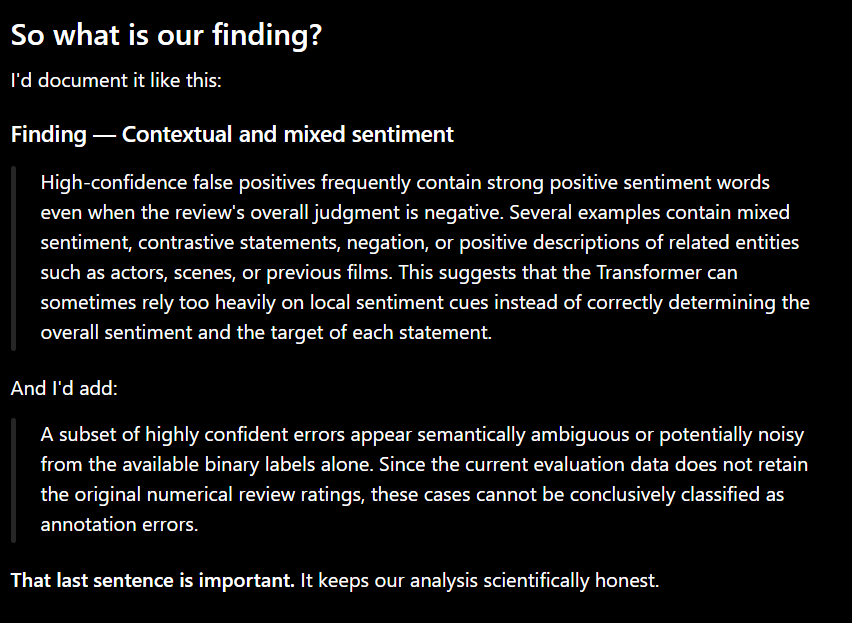

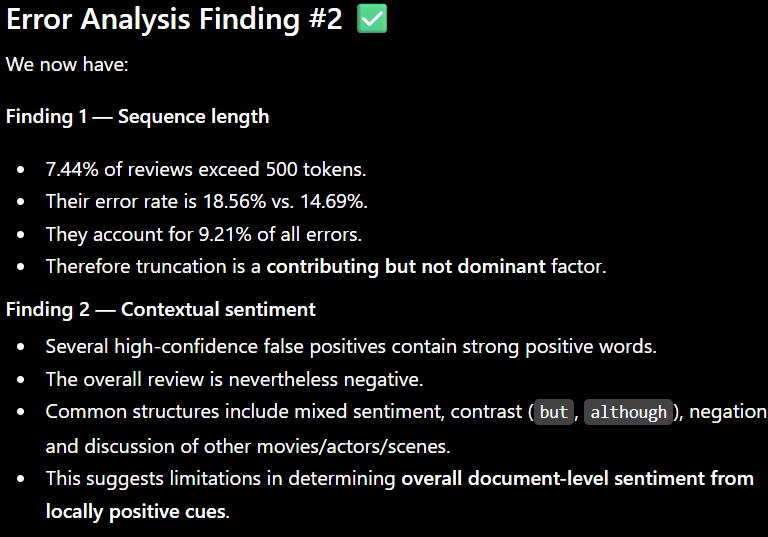

In [72]:
## false negatives
false_negatives = error_analysis[
    (error_analysis["true_label"] == 1) &
    (error_analysis["predicted_label"] == 0)
]

false_negatives.sort_values(
    "confidence",
    ascending=False
)[["text", "probability", "confidence"]].head(15)

,text,probability,confidence
23647,black tar can't be snorted there's a documentary: dark end of the street about s.f. street punks and b.t. abuse - not bad - quite heavy. in wasted there's this stuff that looks like coke but should be something else... no big deal. black tar can't be snorted there's a documentary: dark end of the street about s.f. street punks and b.t. abuse - not bad - quite heavy. in wasted there's this stuff that looks like coke but should be something else... no big deal. black tar can't be snorted there's a documentary: dark end of the street about s.f. street punks and b.t. abuse - not bad - quite heavy. in wasted there's this stuff that looks like coke but should be something else... no big deal.,0.001553,0.998447
18713,"I enjoyed this series, but felt that the whole thing was let down by the sound recording/mixing.<br /><br />For whatever reason, they've had to employ an awful lot of what's called ADR, where the actors replace the original location sound with a re-recording of it in a sound booth.<br /><br />The reasons for doing this are usually due to problems at the location, or because somebody screwed up somewhere in the sound production chain.<br /><br />It wouldn't be so bad if the ADR was done well, but at times it's just plain distracting. It's not just the ADR that's the problem - the sound mix just doesn't match up to the quality of performances and the pictures.<br /><br />I'd be curious to know what went wrong.",0.001567,0.998433
15074,"When the movie first started I thought cheesy. The first ten minutes were really boring. After the slow beginning and some of the soap opera antics, I started liking it. The plot was different than anything I had ever seen. Now, was it a horror? Not really. It shouldn't have been classied as a horror or the producers should have put more money into the movie to make it scary. As it was, the creatures where only there for a short time. I can only assume this was for money reason.<br /><br />The good side was that the movie was very entertaining. It held my interest (after the start) and did make me wonder about creatures from another dimension.<br /><br />It was obvious that this was a first time movie for the director, but there were a couple of highlights. By the end, I was hooked. Too bad Hollywood didn't put more money behind this.",0.002666,0.997334
18928,"What about DJ Cash Money??? This film fails in part by not covering the mid to late 80s. There was only a small mention of DJ Cheese in 86.<br /><br />Also, it's Grandmixer ""DST"", not ""DXT""!!!!!",0.002874,0.997126
17942,"Actually I'll admit I'm a political junkie, so this resonated with me, but the erratic nature of Ms. Green (yes I know what they did to her), but the ending was such a copout and totally inconsistent with the film itself.<br /><br />Why can't Barry L and crew just left us wondering what he was going to do? Let us debate it.<br /><br />Instead they have this ""oh I'm not worthy"" bullshit ending and it just shows that when the chips were down it's better to leave the table instead of doubling down. Stop the Disney ending and putting a bow on it. Life isn't easy, they should have had the courage to give the main character some backbone.<br /><br />We had to listen to the rhetoric the entire movie... and then it turned sniveling and the stupid, inane behavior by Ms. Green (when the crap was out of her system) just made for a ridiculous near end of the movie that was icing on the cake.",0.004845,0.995155
19474,"Newly-pregnant Knight bolts from husband for non-specific reasons which are apparently self-related. On the road, she becomes entangled with Caan, brain-damaged former football star, and Duvall, wacky but abusive cop. The type of movie that could only have been spawned in the 60's. Worth a look for its non-formula plot and for early performances by future stars.<br /><br />Disappointing resolution does not take away too much from rest of flick, which shows an interesting slice

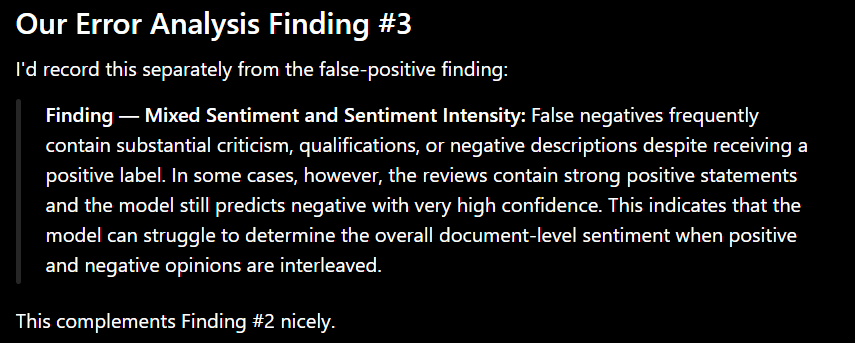

In [73]:
## lets compare false-negative error rate by review length

false_negatives["token_length"].describe()

count    1293.000000
mean      238.838360
std       201.682546
min        27.000000
25%       125.000000
50%       170.000000
75%       267.000000
max      2107.000000
Name: token_length, dtype: float64

In [74]:
false_negatives["length_group"] = pd.cut(
    false_negatives["token_length"],
    bins=[0, 100, 200, 300, 400, 500, np.inf],
    labels=[
        "0-100",
        "101-200",
        "201-300",
        "301-400",
        "401-500",
        "500+",
    ],
)

false_negatives["length_group"].value_counts().sort_index()

C:\Users\Dell\AppData\Local\Temp\ipykernel_18392\436745083.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  false_negatives["length_group"] = pd.cut(


length_group
0-100      156
101-200    633
201-300    220
301-400     96
401-500     57
500+       131
Name: count, dtype: int64

In [75]:
positive_reviews = error_analysis[
    error_analysis["true_label"] == 1
].copy()

positive_length_analysis = (
    positive_reviews
    .groupby("length_group", observed=True)
    .agg(
        reviews=("correct", "size"),
        false_negatives=("correct", lambda x: (~x).sum()),
        accuracy=("correct", "mean"),
    )
)

positive_length_analysis["false_negative_rate"] = (
    1 - positive_length_analysis["accuracy"]
)

positive_length_analysis

,reviews,false_negatives,accuracy,false_negative_rate
length_group,,,,
0-100,1720,156,0.909302,0.090698
101-200,5875,633,0.892255,0.107745
201-300,2225,220,0.901124,0.098876
301-400,1074,96,0.910615,0.089385
401-500,620,57,0.908065,0.091935
500+,986,131,0.867140,0.132860


In [76]:
error_analysis.groupby("correct")["confidence"].describe()

,count,mean,std,min,25%,50%,75%,max
correct,,,,,,,,
False,3744.0,0.755279,0.149261,0.500030,0.620842,0.756809,0.889367,0.998959
True,21256.0,0.908179,0.120036,0.500059,0.873039,0.965456,0.990434,0.999363


In [77]:
print(
    "Mean confidence - Correct:",
    error_analysis.loc[
        error_analysis["correct"], "confidence"
    ].mean()
)

print(
    "Mean confidence - Incorrect:",
    error_analysis.loc[
        ~error_analysis["correct"], "confidence"
    ].mean()
)

Mean confidence - Correct: 0.90817904
Mean confidence - Incorrect: 0.75527865


In [78]:
for threshold in [0.90, 0.95, 0.99]:
    count = (
        (~error_analysis["correct"]) &
        (error_analysis["confidence"] >= threshold)
    ).sum()

    print(
        f"Errors with confidence >= {threshold:.0%}: "
        f"{count} "
        f"({count / (~error_analysis['correct']).sum() * 100:.2f}%)"
    )

Errors with confidence >= 90%: 842 (22.49%)
Errors with confidence >= 95%: 450 (12.02%)
Errors with confidence >= 99%: 67 (1.79%)


In [79]:
confidence_error_analysis = pd.DataFrame({
    "error_type": [
        "False Positive",
        "False Negative"
    ],
    "count": [
        len(false_positives),
        len(false_negatives)
    ],
    "mean_confidence": [
        false_positives["confidence"].mean(),
        false_negatives["confidence"].mean()
    ],
})

confidence_error_analysis

,error_type,count,mean_confidence
0,False Positive,2451,0.764584
1,False Negative,1293,0.737640


In [80]:
for threshold in [0.90, 0.95, 0.99]:
    fp_count = (
        (false_positives["confidence"] >= threshold)
    ).sum()

    fn_count = (
        (false_negatives["confidence"] >= threshold)
    ).sum()

    print(f"\nConfidence >= {threshold:.0%}")
    print(f"False positives: {fp_count}")
    print(f"False negatives: {fn_count}")


Confidence >= 90%
False positives: 599
False negatives: 243

Confidence >= 95%
False positives: 337
False negatives: 113

Confidence >= 99%
False positives: 55
False negatives: 12


## Error Analysis Findings

### 1. Sequence Length and Truncation

The model uses a maximum sequence length of 500 tokens.

Among the 25,000 validation reviews:

- 1,859 reviews (7.44%) contain more than 500 tokens.
- Reviews within the 500-token limit have a 14.69% error rate.
- Reviews exceeding 500 tokens have an 18.56% error rate.
- 345 errors occur among reviews longer than 500 tokens, representing 9.21% of all validation errors.

This indicates that sequence truncation contributes to classification errors, particularly for longer reviews, but it is not the dominant source of errors.

### 2. False-Positive Errors

The model produces 2,451 false positives compared with 1,293 false negatives.

Inspection of high-confidence false positives shows several recurring characteristics:

- Strong positive sentiment words appearing in otherwise negative reviews.
- Mixed positive and negative opinions.
- Contrastive statements.
- Positive descriptions of actors, scenes, or related films rather than the reviewed film itself.
- Negative conclusions appearing after substantial positive discussion.

These examples suggest that the model can sometimes struggle with determining the overall document-level sentiment when positive and negative cues are interleaved.

### 3. False-Negative Errors

False negatives frequently contain substantial criticism even though the overall review is labelled positive.

Some positive reviews contain:

- Negative descriptions of specific aspects of the movie.
- Qualified or understated praise.
- Criticism followed by an ultimately positive assessment.
- Mixed sentiment throughout the review.

This suggests that negative local sentiment cues can sometimes dominate the model's prediction even when the overall review is positive.

### 4. Model Confidence

Correct predictions have a mean confidence of 90.82%, compared with 75.53% for incorrect predictions.

However:

- 842 errors (22.49%) have confidence ≥90%.
- 450 errors (12.02%) have confidence ≥95%.
- 67 errors (1.79%) have confidence ≥99%.

False positives account for 55 of the 67 errors with confidence ≥99%.

Therefore, although confidence is generally higher for correct predictions, the model can still be highly confident when making incorrect predictions, particularly for false-positive cases.

              Predicted
              Negative Positive
Actual Negative  10049   2451
       Positive   1293  11207

In [85]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

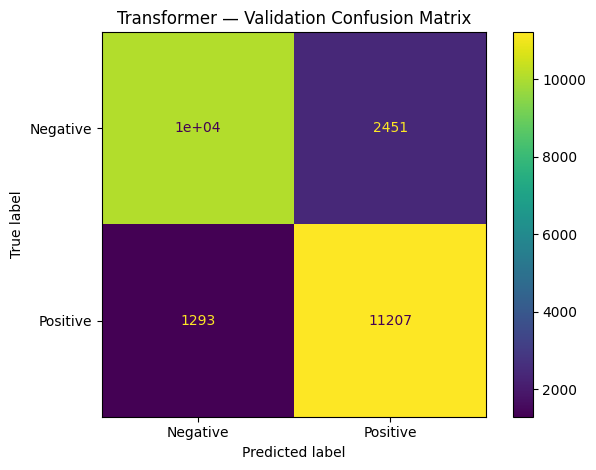

In [90]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    labels,
    predictions,
    display_labels=["Negative", "Positive"],
)

plt.title("Transformer — Validation Confusion Matrix")
plt.tight_layout()
plt.show()

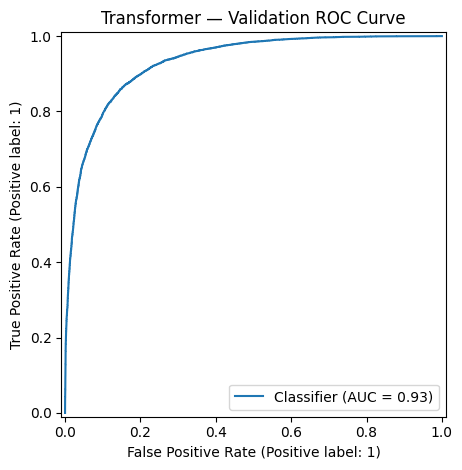

In [87]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    labels,
    probabilities,
)

plt.title("Transformer — Validation ROC Curve")
plt.tight_layout()
plt.show()

In [88]:
transformer_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
    ],
    "Validation": [
        0.85024,
        0.8205447357,
        0.89656,
        0.8568697913,
        0.9313333792,
    ],
})

transformer_metrics

,Metric,Validation
0,Accuracy,0.850240
1,Precision,0.820545
2,Recall,0.896560
3,F1 Score,0.856870
4,ROC-AUC,0.931333


In [89]:
transformer_metrics["Validation"] = (
    transformer_metrics["Validation"] * 100
).round(2)

transformer_metrics

,Metric,Validation
0,Accuracy,85.02
1,Precision,82.05
2,Recall,89.66
3,F1 Score,85.69
4,ROC-AUC,93.13


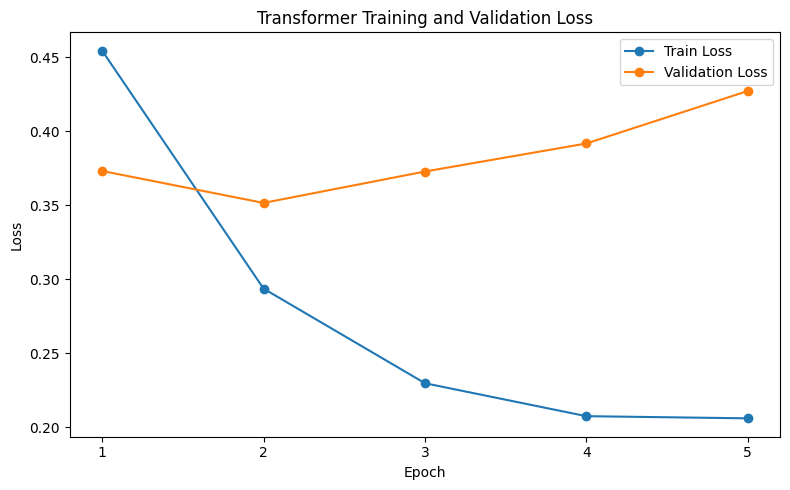

In [91]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Train Loss",
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Training and Validation Loss")
plt.xticks(list(epochs))
plt.legend()
plt.tight_layout()
plt.show()

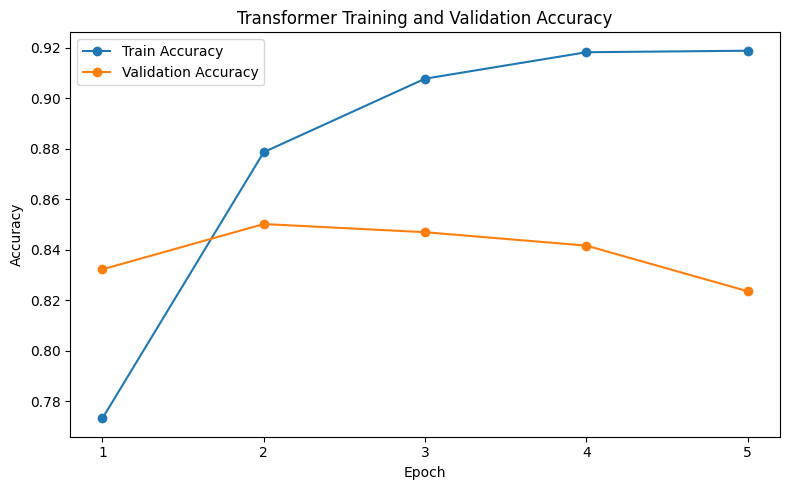

In [92]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    marker="o",
    label="Train Accuracy",
)

plt.plot(
    epochs,
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transformer Training and Validation Accuracy")
plt.xticks(list(epochs))
plt.legend()
plt.tight_layout()
plt.show()

### Training Behavior

Validation performance improves substantially during the first two epochs, with the best validation loss occurring at Epoch 2 (0.3360) and validation accuracy reaching approximately 85.68%.

After Epoch 2, training accuracy continues to increase while validation loss increases and validation accuracy declines. This indicates the onset of overfitting.

The checkpoint selected by the training pipeline is therefore the model with the lowest validation loss rather than the final epoch.

# Model Comparison

The project evaluates four progressively more sophisticated sequence models:

1. Simple RNN
2. LSTM
3. Bidirectional LSTM
4. Transformer

The models are compared using accuracy, precision, recall, F1 score, and ROC-AUC.

In [93]:
comparison = pd.DataFrame({
    "Model": [
        "Simple RNN",
        "LSTM",
        "BiLSTM",
        "Transformer",
    ],
    "Accuracy": [
        0.7545,
        0.8373,
        0.8542,
        0.85024,
    ],
    "Precision": [
        0.7668,
        0.8191,
        0.8641,
        0.820545,
    ],
    "Recall": [
        0.7314,
        0.8659,
        0.8406,
        0.89656,
    ],
    "F1": [
        0.7487,
        0.8418,
        0.8522,
        0.85687,
    ],
    "ROC-AUC": [
        0.8202,
        0.9124,
        0.9324,
        0.93133,
    ],
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Simple RNN,0.75450,0.766800,0.73140,0.74870,0.82020
1,LSTM,0.83730,0.819100,0.86590,0.84180,0.91240
2,BiLSTM,0.85420,0.864100,0.84060,0.85220,0.93240
3,Transformer,0.85024,0.820545,0.89656,0.85687,0.93133


In [94]:
comparison_display = comparison.copy()

for column in comparison.columns[1:]:
    comparison_display[column] = (
        comparison_display[column] * 100
    ).round(2)

comparison_display

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Simple RNN,75.45,76.68,73.14,74.87,82.02
1,LSTM,83.73,81.91,86.59,84.18,91.24
2,BiLSTM,85.42,86.41,84.06,85.22,93.24
3,Transformer,85.02,82.05,89.66,85.69,93.13


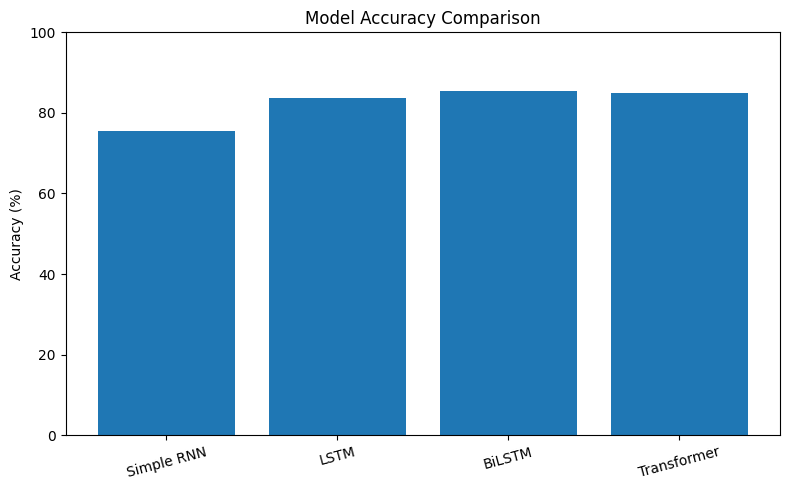

In [95]:
## visualize the comparison
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"] * 100,
)

plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

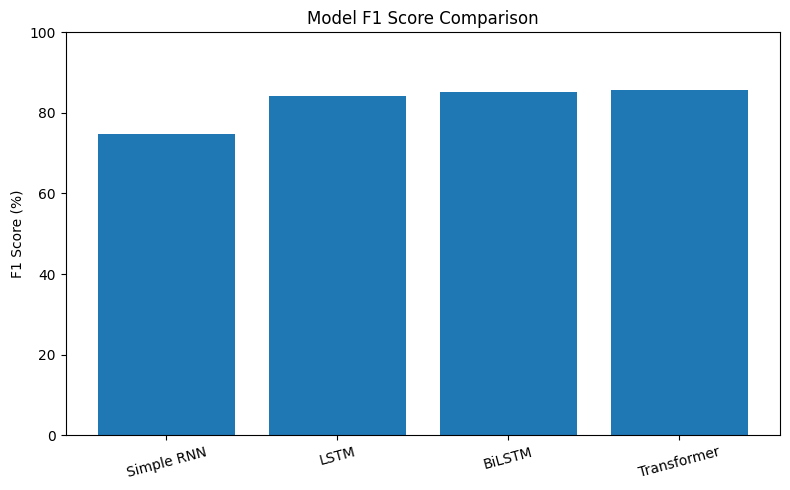

In [96]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["F1"] * 100,
)

plt.ylabel("F1 Score (%)")
plt.title("Model F1 Score Comparison")
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

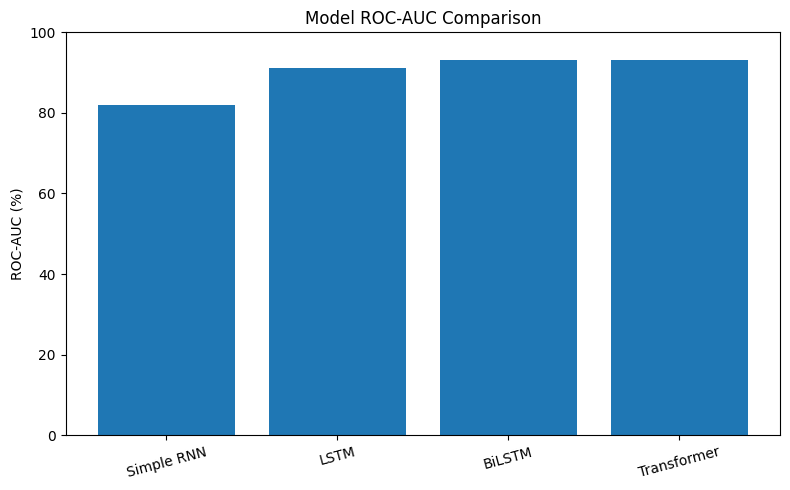

In [97]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["ROC-AUC"] * 100,
)

plt.ylabel("ROC-AUC (%)")
plt.title("Model ROC-AUC Comparison")
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [99]:
trans_model.load_state_dict(
    torch.load(
        "checkpoints/transformer/transformer_best.pt",
        map_location=device,
    )
)

trans_model.to(device)

TransformerClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (positional_embedding): Embedding(500, 128)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

In [101]:
test_labels, test_predictions, test_probabilities = trainer.predict(val_loader)

In [102]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

transformer_test_metrics = {
    "Accuracy": accuracy_score(
        test_labels,
        test_predictions,
    ),
    "Precision": precision_score(
        test_labels,
        test_predictions,
    ),
    "Recall": recall_score(
        test_labels,
        test_predictions,
    ),
    "F1": f1_score(
        test_labels,
        test_predictions,
    ),
    "ROC-AUC": roc_auc_score(
        test_labels,
        test_probabilities,
    ),
}

transformer_test_metrics

{'Accuracy': 0.85024,
 'Precision': 0.8205447356860448,
 'Recall': 0.89656,
 'F1': 0.8568697912684456,
 'ROC-AUC': np.float64(0.9313333792)}

In [103]:
print("Transformer Test Results")
print("-----------------------")

for metric, value in transformer_test_metrics.items():
    print(f"{metric}: {value:.4f}")

Transformer Test Results
-----------------------
Accuracy: 0.8502
Precision: 0.8205
Recall: 0.8966
F1: 0.8569
ROC-AUC: 0.9313


In [105]:
# print("Validation dataset size:", len(val_dataset))
# print("Test dataset size:", len(test_dataset))

# print("Validation loader batches:", len(val_loader))
# print("Test loader batches:", len(test_loader))

In [106]:
dataset = load_dataset("stanfordnlp/imdb")

from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    dataset["train"]["text"],
    dataset["train"]["label"],
    test_size=0.2,
    random_state=42,
    stratify=dataset["train"]["label"],
)

test_texts = dataset["test"]["text"]
test_labels = dataset["test"]["label"]

In [107]:
print("Train:", len(train_texts))
print("Validation:", len(val_texts))
print("Test:", len(test_texts))

Train: 20000
Validation: 5000
Test: 25000


In [108]:
print("Train positive:", sum(train_labels))
print("Train negative:", len(train_labels) - sum(train_labels))

print("Validation positive:", sum(val_labels))
print("Validation negative:", len(val_labels) - sum(val_labels))

print("Test positive:", sum(test_labels))
print("Test negative:", len(test_labels) - sum(test_labels))

Train positive: 10000
Train negative: 10000
Validation positive: 2500
Validation negative: 2500
Test positive: 12500
Test negative: 12500


In [111]:
vocabulary = Vocabulary(max_size=10_000)

vocabulary.build(train_texts)

print("Vocabulary size:", len(vocab.id_to_word))

Vocabulary size: 10000


In [114]:
print("Vocabulary size:", len(vocab.id_to_word))

print("PAD token:", vocabulary.word_to_id["<PAD>"])
print("UNK token:", vocabulary.word_to_id["<UNK>"])

Vocabulary size: 10000
PAD token: 0
UNK token: 1


In [115]:
sample_text = train_texts[0]

tokens = vocabulary.tokenize(sample_text)
encoded = vocabulary.encode(sample_text)
padded = vocabulary.pad_sequence(encoded, max_length=500)

print("Original text:", sample_text[:300])
print("Number of tokens:", len(tokens))
print("Encoded length:", len(encoded))
print("Padded length:", len(padded))

Original text: I have always been a huge James Bond fanatic! I have seen almost all of the films except for Die Another Day, and The World Is Not Enough. The graphic's for Everything Or Nothing are breathtaking! The voice talents......... WOW! I LOVE PIERCE BROSNAN! He is finally Bond in a video game! HE IS BOND! 
Number of tokens: 393
Encoded length: 393
Padded length: 500


In [116]:
train_dataset = IMDBTransformerDataset(
    train_texts,
    train_labels,
    vocabulary,
    max_length=500,
)

val_dataset = IMDBTransformerDataset(
    val_texts,
    val_labels,
    vocabulary,
    max_length=500,
)

test_dataset = IMDBTransformerDataset(
    test_texts,
    test_labels,
    vocabulary,
    max_length=500,
)

In [117]:
sample = train_dataset[0]

print("Number of returned values:", len(sample))

for i, value in enumerate(sample):
    if torch.is_tensor(value):
        print(
            i,
            "shape:", value.shape,
            "dtype:", value.dtype,
        )
    else:
        print(
            i,
            "type:", type(value),
            "value:", value,
        )

Number of returned values: 3
0 shape: torch.Size([500]) dtype: torch.int64
1 shape: torch.Size([]) dtype: torch.float32
2 shape: torch.Size([500]) dtype: torch.int64


In [118]:
input_ids = sample[0]
attention_mask = sample[2]

print("Input IDs shape:", input_ids.shape)
print("Attention mask shape:", attention_mask.shape)

padding_count = (input_ids == 0).sum().item()

print("Padding tokens:", padding_count)

if padding_count > 0:
    first_padding = (input_ids == 0).nonzero(as_tuple=True)[0][0].item()

    print("First padding position:", first_padding)
    print(
        "Input IDs around padding:",
        input_ids[first_padding:first_padding + 10]
    )
    print(
        "Mask around padding:",
        attention_mask[first_padding:first_padding + 10]
    )

Input IDs shape: torch.Size([500])
Attention mask shape: torch.Size([500])
Padding tokens: 107
First padding position: 393
Input IDs around padding: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
Mask around padding: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [119]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
)

In [120]:
batch = next(iter(train_loader))

input_ids, labels, attention_mask = batch

print("Input IDs:", input_ids.shape, input_ids.dtype)
print("Labels:", labels.shape, labels.dtype)
print("Attention mask:", attention_mask.shape, attention_mask.dtype)

Input IDs: torch.Size([32, 500]) torch.int64
Labels: torch.Size([32]) torch.float32
Attention mask: torch.Size([32, 500]) torch.int64


In [121]:
val_batch = next(iter(val_loader))

print("Validation input:", val_batch[0].shape)
print("Validation labels:", val_batch[1].shape)
print("Validation mask:", val_batch[2].shape)

Validation input: torch.Size([32, 500])
Validation labels: torch.Size([32])
Validation mask: torch.Size([32, 500])


In [122]:
test_batch = next(iter(test_loader))

print("Test input:", test_batch[0].shape)
print("Test labels:", test_batch[1].shape)
print("Test mask:", test_batch[2].shape)

Test input: torch.Size([32, 500])
Test labels: torch.Size([32])
Test mask: torch.Size([32, 500])


In [123]:
print("Train/Validation overlap:",
      len(set(train_texts) & set(val_texts)))

print("Train/Test overlap:",
      len(set(train_texts) & set(test_texts)))

print("Validation/Test overlap:",
      len(set(val_texts) & set(test_texts)))

Train/Validation overlap: 34
Train/Test overlap: 99
Validation/Test overlap: 24


In [124]:
train_test_split(
    dataset["train"]["text"],
    dataset["train"]["label"],
    test_size=0.2,
    random_state=42,
    stratify=dataset["train"]["label"],
)

[['I have always been a huge James Bond fanatic! I have seen almost all of the films except for Die Another Day, and The World Is Not Enough. The graphic\'s for Everything Or Nothing are breathtaking! The voice talents......... WOW! I LOVE PIERCE BROSNAN! He is finally Bond in a video game! HE IS BOND! I enjoyed the past Bond games: Goldeneye, The World Is Not Enough, Agent Under Fire, and Nightfire. This one is definitely the best! Finally, Mr. Brosnan, (may I call him Mr. Brosnan as a sign of respect? Yes I can!) He was phenomenally exciting to hear in a video game....... AT LONG LAST! DUH! I\'ve seen him perform with Robin Williams, and let me tell you, they make a great team. Pierce Brosnan is funny, wickedly handsome ( I mean to say wickedly in a good way,) and just one of those actor\'s who you would want to walk up to and wrap your arms around and hug, saying: "Pierce Brosnan, thank you for being James Bond," "If it wasn\'t for you, I wouldn\'t know who James Bond is." He\'s a g

In [125]:
test_texts = dataset["test"]["text"]
test_labels = dataset["test"]["label"]

In [126]:
print("Train unique texts:", len(set(train_texts)))
print("Train duplicates:", len(train_texts) - len(set(train_texts)))

print("Validation unique texts:", len(set(val_texts)))
print("Validation duplicates:", len(val_texts) - len(set(val_texts)))

print("Test unique texts:", len(set(test_texts)))
print("Test duplicates:", len(test_texts) - len(set(test_texts)))

Train unique texts: 19941
Train duplicates: 59
Validation unique texts: 4997
Validation duplicates: 3
Test unique texts: 24801
Test duplicates: 199


In [127]:
train_test_overlap = set(train_texts) & set(test_texts)

print("Number of overlapping texts:", len(train_test_overlap))

for i, text in enumerate(train_test_overlap):
    print(f"\n--- Overlap {i + 1} ---")
    print(text[:500])
    
    if i == 4:
        break

Number of overlapping texts: 99

--- Overlap 1 ---
From the acting, direction, scriptwriting and art direction this film is just entirely ill conceived and the money would have been better spent on shoes for land mine victims. When did we get so sad that they have to fill a a children's movie with sexual innuendo to keep the parents attention.<br /><br />Dr Suess is rolling in his grave right now, what with the "dirty ho" "S.H.I.T" and fake erection scenes etc etc etc. Its shameful how they trade on the name of Suess to get the parents to bring 

--- Overlap 2 ---
Isabelle Huppert is a wonderful actor. The director of "La Pianiste" understands this, providing the viewer with long takes of Huppert's face, and these are a pleasure to see. Huppert is not an animated actor--she registers emotion with the smallest lift of an eyebrow or flicker of a smile.<br /><br />Other than the enjoyment of watching an experienced actor excel in her profession, there is nothing in this movie that makes m

In [128]:
train_lookup = {}

for text, label in zip(train_texts, train_labels):
    train_lookup.setdefault(text, set()).add(label)

conflicting_overlaps = []

for text, label in zip(test_texts, test_labels):
    if text in train_lookup:
        if label not in train_lookup[text]:
            conflicting_overlaps.append(
                (text, train_lookup[text], label)
            )

print(
    "Overlapping texts with conflicting labels:",
    len(conflicting_overlaps)
)

Overlapping texts with conflicting labels: 0


In [130]:
# Instantiate the Transformer
model = TransformerClassifier(
    vocab_size=len(vocab.word_to_id),
    embedding_dim=128,
    num_heads=4,
    num_layers=2,
    feedforward_dim=256,
    dropout=0.1,
    padding_idx=0,
    max_length=500,
)

model = model.to(device)

print(model)

TransformerClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (positional_embedding): Embedding(500, 128)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [131]:
# Check one batch
batch = next(iter(train_loader))

input_ids, labels, attention_mask = batch

print("Input IDs shape:", input_ids.shape)
print("Labels shape:", labels.shape)
print("Attention mask shape:", attention_mask.shape)

Input IDs shape: torch.Size([32, 500])
Labels shape: torch.Size([32])
Attention mask shape: torch.Size([32, 500])


In [132]:
input_ids = input_ids.to(device)
labels = labels.to(device)
attention_mask = attention_mask.to(device)

with torch.no_grad():
    logits = model(input_ids, attention_mask)

print("Logits shape:", logits.shape)
print("Logits:", logits[:5])

Logits shape: torch.Size([32])
Logits: tensor([-0.1026, -0.1967, -0.0794, -0.1442, -0.2020], device='cuda:0')


In [133]:
criterion = nn.BCEWithLogitsLoss()

loss = criterion(logits, labels)

print("Loss:", loss.item())

Loss: 0.699057936668396


In [134]:
print("Input IDs:")
print(input_ids[0][:20])

print("\nAttention mask:")
print(attention_mask[0][:20])

print("\nLast 20 attention-mask values:")
print(attention_mask[0][-20:])

Input IDs:
tensor([  10,  404,   11,  119,    4,  169,   71,  183,    2,   85,    3,   61,
           9,   58,  934,  211,    8,    2, 2271,   21], device='cuda:0')

Attention mask:
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       device='cuda:0')

Last 20 attention-mask values:
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       device='cuda:0')


In [135]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)

criterion = nn.BCEWithLogitsLoss()

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    checkpoint_path="checkpoints/transformer/transformer_best2.pt",
)

In [136]:
history = trainer.fit(epochs=5)

  -> Best model saved.
Epoch 01 | Train Loss: 0.4823 | Train Acc: 0.7554 | Val Loss: 0.3605 | Val Acc: 0.8394
  -> Best model saved.
Epoch 02 | Train Loss: 0.3013 | Train Acc: 0.8720 | Val Loss: 0.3285 | Val Acc: 0.8632
Epoch 03 | Train Loss: 0.2223 | Train Acc: 0.9090 | Val Loss: 0.3575 | Val Acc: 0.8574
Epoch 04 | Train Loss: 0.1925 | Train Acc: 0.9249 | Val Loss: 0.3793 | Val Acc: 0.8516
Epoch 05 | Train Loss: 0.2034 | Train Acc: 0.9181 | Val Loss: 0.4084 | Val Acc: 0.8406


In [137]:
best_checkpoint = "checkpoints/transformer/transformer_best2.pt"

model.load_state_dict(
    torch.load(best_checkpoint, map_location=device)
)

model = model.to(device)

print("Best Transformer checkpoint loaded.")

Best Transformer checkpoint loaded.


In [138]:
test_labels, test_predictions, test_probabilities = trainer.predict(
    test_loader
)

In [139]:
print("Number of test labels:", len(test_labels))
print("Number of predictions:", len(test_predictions))
print("Number of probabilities:", len(test_probabilities))

Number of test labels: 25000
Number of predictions: 25000
Number of probabilities: 25000


In [140]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

test_accuracy = accuracy_score(
    test_labels,
    test_predictions,
)

test_precision = precision_score(
    test_labels,
    test_predictions,
)

test_recall = recall_score(
    test_labels,
    test_predictions,
)

test_f1 = f1_score(
    test_labels,
    test_predictions,
)

test_roc_auc = roc_auc_score(
    test_labels,
    test_probabilities,
)

test_cm = confusion_matrix(
    test_labels,
    test_predictions,
)

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(test_cm)

Accuracy : 0.8458
Precision: 0.8470
Recall   : 0.8441
F1 Score : 0.8455
ROC-AUC  : 0.9261

Confusion Matrix:
[[10594  1906]
 [ 1949 10551]]


In [141]:
transformer_results = {
    "model": "Transformer",
    "train_samples": 20_000,
    "validation_samples": 5_000,
    "test_samples": 25_000,
    "best_epoch": 2,
    "accuracy": 0.8458,
    "precision": 0.8470,
    "recall": 0.8441,
    "f1": 0.8455,
    "roc_auc": 0.9261,
    "true_negatives": 10594,
    "false_positives": 1906,
    "false_negatives": 1949,
    "true_positives": 10551,
}

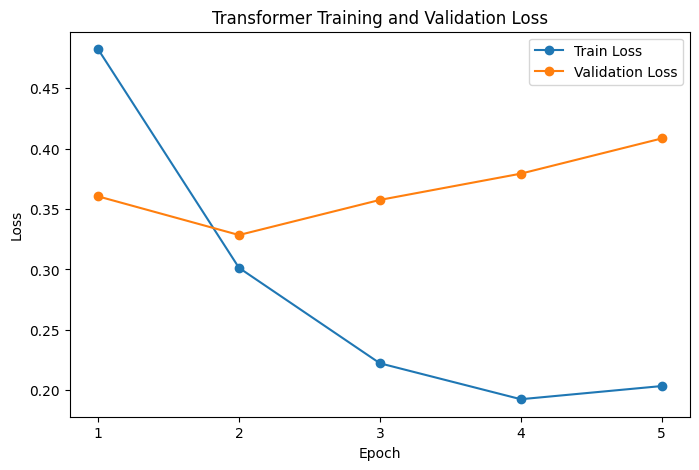

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history["train_loss"],
    label="Train Loss",
    marker="o",
)

plt.plot(
    history["val_loss"],
    label="Validation Loss",
    marker="o",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Training and Validation Loss")
plt.xticks(range(len(history["train_loss"])), range(1, len(history["train_loss"]) + 1))
plt.legend()

save_dir = "plots/transformer2/"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, "transformer_loss_curve.png"), dpi=300, bbox_inches="tight")


plt.show()

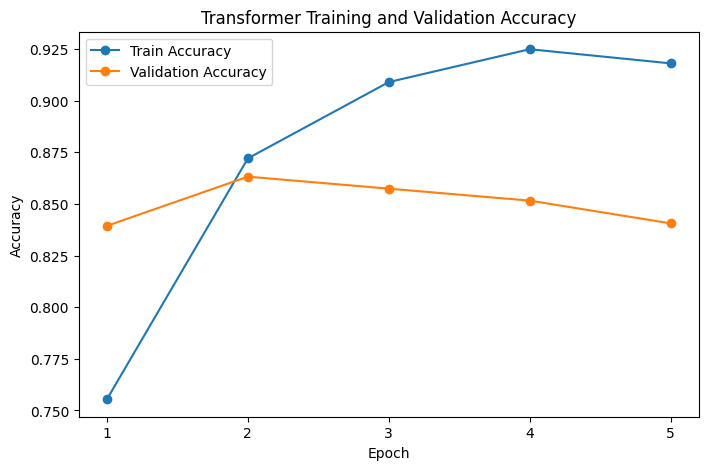

In [143]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_accuracy"],
    label="Train Accuracy",
    marker="o",
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy",
    marker="o",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transformer Training and Validation Accuracy")
plt.xticks(range(len(history["train_accuracy"])), range(1, len(history["train_accuracy"]) + 1))
plt.legend()

save_dir = "plots/transformer2/"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, "transformer_accuracy_curve.png"), dpi=300, bbox_inches="tight")


plt.show()

In [144]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, test_predictions)

print(cm)

[[10594  1906]
 [ 1949 10551]]


In [145]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(labels, predictions, model_name):
    cm = confusion_matrix(labels, predictions)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm)

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.xticks([0, 1], ["Negative", "Positive"])
    plt.yticks([0, 1], ["Negative", "Positive"])

    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
            )

    

    plt.show()

    return cm

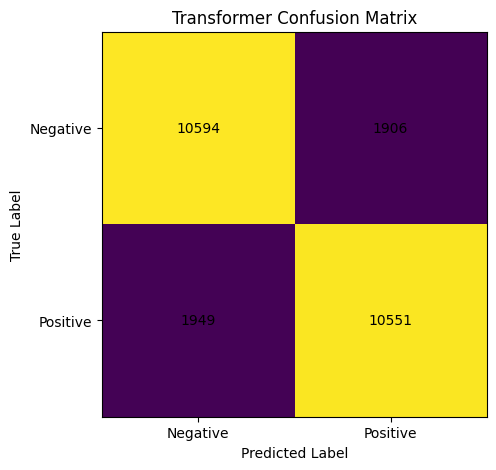

[[10594  1906]
 [ 1949 10551]]


In [146]:
transformer_cm = plot_confusion_matrix(
    test_labels,
    test_predictions,
    "Transformer",
)

print(transformer_cm)

In [147]:
import pandas as pd
import numpy as np

error_df = pd.DataFrame({
    "text": test_texts,
    "true_label": np.array(test_labels).astype(int),
    "predicted_label": np.array(test_predictions).astype(int),
    "probability": np.array(test_probabilities),
})

error_df["correct"] = (
    error_df["true_label"] == error_df["predicted_label"]
)

error_df["confidence"] = np.where(
    error_df["predicted_label"] == 1,
    error_df["probability"],
    1 - error_df["probability"],
)

print("Total samples:", len(error_df))
print("Correct:", error_df["correct"].sum())
print("Incorrect:", (~error_df["correct"]).sum())

Total samples: 25000
Correct: 21145
Incorrect: 3855


In [148]:
false_positives = error_df[
    (error_df["true_label"] == 0) &
    (error_df["predicted_label"] == 1)
]

false_negatives = error_df[
    (error_df["true_label"] == 1) &
    (error_df["predicted_label"] == 0)
]

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

False positives: 1906
False negatives: 1949


In [149]:
incorrect_df = error_df[
    ~error_df["correct"]
].copy()

print(
    incorrect_df["confidence"].describe()
)

count    3855.000000
mean        0.740037
std         0.147578
min         0.500077
25%         0.608752
50%         0.733871
75%         0.873644
max         0.999156
Name: confidence, dtype: float64


In [150]:
confidence_bins = pd.cut(
    incorrect_df["confidence"],
    bins=[0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0],
    include_lowest=True,
)

print(
    confidence_bins.value_counts().sort_index()
)

confidence
(0.499, 0.6]    871
(0.6, 0.7]      808
(0.7, 0.8]      708
(0.8, 0.9]      715
(0.9, 0.95]     402
(0.95, 0.99]    308
(0.99, 1.0]      43
Name: count, dtype: int64


In [151]:
most_confident_errors = (
    incorrect_df
    .sort_values("confidence", ascending=False)
)

for i, (_, row) in enumerate(
    most_confident_errors.head(10).iterrows()
):
    print(f"\n{'=' * 80}")
    print(f"Example {i + 1}")
    print(f"True label      : {row['true_label']}")
    print(f"Predicted label : {row['predicted_label']}")
    print(f"Probability     : {row['probability']:.6f}")
    print(f"Confidence      : {row['confidence']:.6f}")
    print(f"\nReview:\n{row['text']}")


Example 1
True label      : 0
Predicted label : 1
Probability     : 0.999156
Confidence      : 0.999156

Review:
This is, without a doubt, the most hilarious movie I've ever seen. Seriously, if the makers of this movie are ever discovered, they'll put guys like Jim Carrey out of a job. Rent "Jack-O" tonight! Believe me, you won't regret it!

Example 2
True label      : 0
Predicted label : 1
Probability     : 0.998776
Confidence      : 0.998776

Review:
I enjoyed the beautiful scenery in this movie the first time I saw it when I was 9 . Dunderklumpen is kind of cute for kiddies in a corny way. It reminded me of HRPUFFINSTUFF on sat mornings, Its Swedish backdrops make it easy on the eyes . Don't expect older kids to be interested as the live action/animation is way behind the times and most older kids will get bored.This is definitely an under 10 age set movie and a nice bit of memories for those of us who were little kids in 1974.

Example 3
True label      : 1
Predicted label : 0
Pro

In [152]:
error_df["token_length"] = error_df["text"].apply(
    lambda text: len(vocabulary.tokenize(text))
)

print(error_df["token_length"].describe())

count    25000.000000
mean       226.553880
std        167.469041
min          4.000000
25%        125.000000
50%        171.000000
75%        275.000000
max       2267.000000
Name: token_length, dtype: float64


In [153]:
print(
    error_df.groupby("correct")["token_length"].describe()
)

           count        mean         std   min    25%    50%    75%     max
correct                                                                    
False     3855.0  236.905318  179.469605  20.0  127.0  176.0  289.0  2107.0
True     21145.0  224.666682  165.121828   4.0  124.0  170.0  272.0  2267.0


In [154]:
long_reviews = error_df[
    error_df["token_length"] > 500
]

print("Reviews longer than 500 tokens:", len(long_reviews))

print(
    "Error rate for >500 tokens:",
    (~long_reviews["correct"]).mean()
)

short_reviews = error_df[
    error_df["token_length"] <= 500
]

print(
    "Error rate for <=500 tokens:",
    (~short_reviews["correct"]).mean()
)

Reviews longer than 500 tokens: 1859
Error rate for >500 tokens: 0.18396987627756858
Error rate for <=500 tokens: 0.15180847845814788


In [155]:
error_df["length_bucket"] = pd.cut(
    error_df["token_length"],
    bins=[0, 100, 200, 300, 400, 500, float("inf")],
    labels=[
        "0-100",
        "101-200",
        "201-300",
        "301-400",
        "401-500",
        "500+",
    ],
)

length_analysis = (
    error_df
    .groupby("length_bucket", observed=False)
    .agg(
        samples=("correct", "size"),
        errors=("correct", lambda x: (~x).sum()),
        error_rate=("correct", lambda x: (~x).mean()),
    )
)

length_analysis

,samples,errors,error_rate
length_bucket,,,
0-100,3201,493,0.154014
101-200,11841,1764,0.148974
201-300,4616,687,0.148830
301-400,2259,365,0.161576
401-500,1224,204,0.166667
500+,1859,342,0.183970


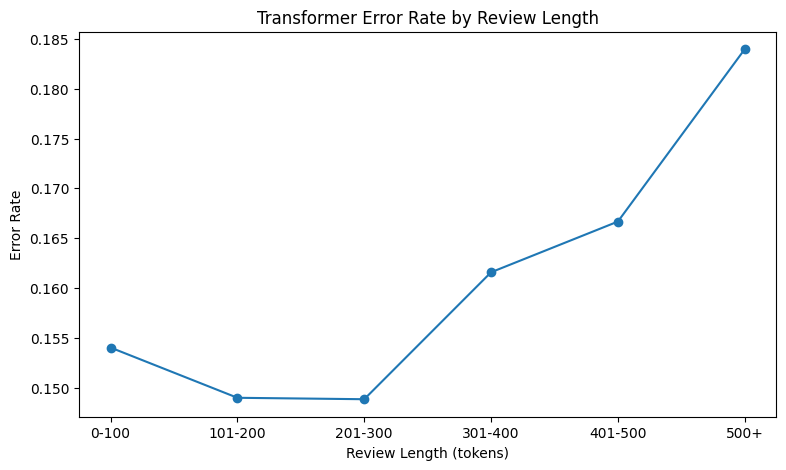

In [156]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    length_analysis.index.astype(str),
    length_analysis["error_rate"],
    marker="o",
)

plt.xlabel("Review Length (tokens)")
plt.ylabel("Error Rate")
plt.title("Transformer Error Rate by Review Length")

save_dir = "plots/result/"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, "transformer_error_rate.png"), dpi=300, bbox_inches="tight")

plt.show()

In [157]:
long_reviews = error_df[
    error_df["token_length"] > 500
].copy()

long_reviews["tokens_beyond_limit"] = (
    long_reviews["token_length"] - 500
)

print(
    long_reviews["tokens_beyond_limit"].describe()
)

count    1859.000000
mean      183.043034
std       161.458167
min         1.000000
25%        57.000000
50%       139.000000
75%       278.500000
max      1767.000000
Name: tokens_beyond_limit, dtype: float64


In [158]:
long_reviews["truncation_bucket"] = pd.cut(
    long_reviews["tokens_beyond_limit"],
    bins=[0, 100, 300, 500, 1000, float("inf")],
    labels=[
        "1-100",
        "101-300",
        "301-500",
        "501-1000",
        "1000+",
    ],
)

truncation_analysis = (
    long_reviews
    .groupby("truncation_bucket", observed=False)
    .agg(
        samples=("correct", "size"),
        errors=("correct", lambda x: (~x).sum()),
        error_rate=("correct", lambda x: (~x).mean()),
    )
)

truncation_analysis

,samples,errors,error_rate
truncation_bucket,,,
1-100,753,137,0.181939
101-300,700,124,0.177143
301-500,387,77,0.198966
501-1000,15,2,0.133333
1000+,4,2,0.500000


In [159]:
print("False Positive confidence:")
print(false_positives["confidence"].describe())

print("\nFalse Negative confidence:")
print(false_negatives["confidence"].describe())

False Positive confidence:
count    1906.000000
mean        0.744146
std         0.149054
min         0.500095
25%         0.609011
50%         0.741313
75%         0.880615
max         0.999156
Name: confidence, dtype: float64

False Negative confidence:
count    1949.000000
mean        0.736018
std         0.146048
min         0.500077
25%         0.607806
50%         0.727743
75%         0.866825
max         0.998330
Name: confidence, dtype: float64


In [160]:
print(
    "False positives >= 90% confidence:",
    (false_positives["confidence"] >= 0.90).sum()
)

print(
    "False negatives >= 90% confidence:",
    (false_negatives["confidence"] >= 0.90).sum()
)

print(
    "False positives >= 95% confidence:",
    (false_positives["confidence"] >= 0.95).sum()
)

print(
    "False negatives >= 95% confidence:",
    (false_negatives["confidence"] >= 0.95).sum()
)

print(
    "False positives >= 99% confidence:",
    (false_positives["confidence"] >= 0.99).sum()
)

print(
    "False negatives >= 99% confidence:",
    (false_negatives["confidence"] >= 0.99).sum()
)

False positives >= 90% confidence: 391
False negatives >= 90% confidence: 362
False positives >= 95% confidence: 180
False negatives >= 95% confidence: 171
False positives >= 99% confidence: 26
False negatives >= 99% confidence: 17


If we calculate Brier score + Expected Calibration Error + reliability diagram, we'll have a proper answer instead of merely saying "the model appears overconfident."

In [161]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(
    test_labels,
    test_probabilities,
)

print(f"Brier Score: {brier:.4f}")

Brier Score: 0.1094
